[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/modules/06_model_evaluation/ch06-BAJ.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/modules/06_model_evaluation/ch06-BAJ.ipynb)


# Model Evaluation and Hyperparameter Tuning


## Package version checks

Add folder to path in order to load from the check_packages.py script:

In [1]:
# (Removed local-repo sys.path hack; not needed on Colab.)


Check recommended package versions:

In [2]:
# Report installed package versions (no external helper script needed on Colab).
import importlib.metadata as importlib_metadata

for pkg in ['numpy', 'matplotlib', 'scikit-learn', 'pandas']:
    try:
        print(f'{pkg}: {importlib_metadata.version(pkg)}')
    except importlib_metadata.PackageNotFoundError:
        print(f'{pkg}: NOT INSTALLED')


numpy: 2.0.2
matplotlib: 3.10.0
scikit-learn: 1.6.1
pandas: 2.2.2


# Chapter 6 - Learning Best Practices for Model Evaluation and Hyperparameter Tuning

<br>
<br>

### Overview

- [Streamlining workflows with pipelines](#Streamlining-workflows-with-pipelines)
  - [Loading the Breast Cancer Wisconsin dataset](#Loading-the-Breast-Cancer-Wisconsin-dataset)
  - [Combining transformers and estimators in a pipeline](#Combining-transformers-and-estimators-in-a-pipeline)
- [Using k-fold cross-validation to assess model performance](#Using-k-fold-cross-validation-to-assess-model-performance)
  - [The holdout method](#The-holdout-method)
  - [K-fold cross-validation](#K-fold-cross-validation)
- [Debugging algorithms with learning and validation curves](#Debugging-algorithms-with-learning-and-validation-curves)
  - [Diagnosing bias and variance problems with learning curves](#Diagnosing-bias-and-variance-problems-with-learning-curves)
  - [Addressing overfitting and underfitting with validation curves](#Addressing-overfitting-and-underfitting-with-validation-curves)
- [Fine-tuning machine learning models via grid search](#Fine-tuning-machine-learning-models-via-grid-search)
  - [Tuning hyperparameters via grid search](#Tuning-hyperparameters-via-grid-search)
  - [Exploring hyperparameter configurations more widely with randomized search](#Exploring-hyperparameter-configurations-more-widely-with-randomized-search)
  - [More resource-efficient hyperparameter search with successive
halving](#More-resource-efficient-hyperparameter-search-with-successive-halving)
  - [Algorithm selection with nested cross-validation](#Algorithm-selection-with-nested-cross-validation)
- [Looking at different performance evaluation metrics](#Looking-at-different-performance-evaluation-metrics)
  - [Reading a confusion matrix](#Reading-a-confusion-matrix)
  - [Optimizing the precision and recall of a classification model](#Optimizing-the-precision-and-recall-of-a-classification-model)
  - [Plotting a receiver operating characteristic](#Plotting-a-receiver-operating-characteristic)
  - [The scoring metrics for multiclass classification](#The-scoring-metrics-for-multiclass-classification)
- [Dealing with class imbalance](#Dealing-with-class-imbalance)
- [Summary](#Summary)

<br>
<br>

In [3]:
from IPython.display import Image
%matplotlib inline

import os
os.makedirs('figures', exist_ok=True)  # so plt.savefig(...) calls below don't fail on Colab

# Figures referenced by this notebook live in the companion GitHub repo;
# fetch them by URL since a fresh Colab runtime won't have the local 'figures/' folder populated.
FIGURES_BASE_URL = (
    'https://raw.githubusercontent.com/brianjalaian/CAP6606_ML_ISR/'
    'main/modules/06_model_evaluation/figures'
)


# Streamlining workflows with pipelines

...

## Loading the Breast Cancer Wisconsin dataset

In [4]:
import pandas as pd

wdbc_url = (
    'https://raw.githubusercontent.com/brianjalaian/CAP6606_ML_ISR/'
    'main/modules/06_model_evaluation/wdbc.data'
)

try:
    df = pd.read_csv(wdbc_url, header=None)
except Exception as e:
    # Fall back to the identical Breast Cancer Wisconsin (Diagnostic) dataset
    # bundled with scikit-learn, reshaped into the same layout as wdbc.data
    # (id, diagnosis M/B, 30 feature columns).
    print(f'GitHub download failed ({e}); falling back to sklearn.datasets.load_breast_cancer().')
    from sklearn.datasets import load_breast_cancer
    bc = load_breast_cancer()
    diagnosis = pd.Series(bc.target).map({0: 'M', 1: 'B'})  # sklearn: 0=malignant, 1=benign
    df = pd.concat(
        [pd.Series(range(1, len(bc.target) + 1), name=0),
         diagnosis.rename(1),
         pd.DataFrame(bc.data, columns=range(2, 2 + bc.data.shape[1]))],
        axis=1)

df.head()


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df.shape

(569, 32)

<hr>

In [6]:
from sklearn.preprocessing import LabelEncoder

X = df.loc[:, 2:].values
y = df.loc[:, 1].values
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [7]:
le.transform(['M', 'B'])

array([1, 0])

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(X, y,
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

<br>
<br>

## Combining transformers and estimators in a pipeline

This cell demonstrates how to create a machine learning pipeline using Scikit-Learn. A pipeline sequentially applies a list of transforms and a final estimator. Intermediate steps of the pipeline must be transformers (i.e., they must implement fit and transform methods). The final estimator only needs to implement fit.

In this example, the pipeline consists of three steps:

1. `StandardScaler()` - Standardize features by removing the mean and scaling to unit variance.
2. `PCA(n_components=2)` - Apply Principal Component Analysis to reduce the dimensionality of the data to two principal components.
3. `LogisticRegression()` - Apply a Logistic Regression model to the transformed data.

The pipeline is then fitted to the training data and used to predict the labels of the test data. The accuracy of the model on the test data is then printed.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression())

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
test_acc = pipe_lr.score(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')

Test accuracy: 0.956


In [10]:
Image(url=f'{FIGURES_BASE_URL}/06_01.png', width=500)


<br>
<br>

# Using k-fold cross validation to assess model performance

...

## The holdout method

In [11]:
Image(url=f'{FIGURES_BASE_URL}/06_02.png', width=500)


<br>
<br>

## K-fold cross-validation

In [12]:
Image(url=f'{FIGURES_BASE_URL}/06_03.png', width=500)


This cell demonstrates how to use k-fold cross validation to assess the performance of the machine learning pipeline created in the previous section. It uses the StratifiedKFold class from scikit-learn, which is a variation of k-fold that returns stratified folds: each set contains approximately the same percentage of samples of each target class as the complete set.

First, a `StratifiedKFold` object is created with 10 splits, and the `split` method is called with the training data to generate the indices for the training and validation sets for each fold.

Then, a for loop is used to iterate over the folds. For each fold, the pipeline is fitted to the training data, and the accuracy of the pipeline on the validation data is calculated and stored in the `scores` list.

Finally, the mean and standard deviation of the cross-validation accuracies are printed.

In [13]:
import numpy as np
from sklearn.model_selection import StratifiedKFold


kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)

scores = []
for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)

    print(f'Fold: {k+1:02d}, '
          f'Class distr.: {np.bincount(y_train[train])}, '
          f'Acc.: {score:.3f}')

mean_acc = np.mean(scores)
std_acc = np.std(scores)
print(f'\nCV accuracy: {mean_acc:.3f} +/- {std_acc:.3f}')

Fold: 01, Class distr.: [256 153], Acc.: 0.935
Fold: 02, Class distr.: [256 153], Acc.: 0.935
Fold: 03, Class distr.: [256 153], Acc.: 0.957
Fold: 04, Class distr.: [256 153], Acc.: 0.957
Fold: 05, Class distr.: [256 153], Acc.: 0.935
Fold: 06, Class distr.: [257 153], Acc.: 0.956
Fold: 07, Class distr.: [257 153], Acc.: 0.978
Fold: 08, Class distr.: [257 153], Acc.: 0.933
Fold: 09, Class distr.: [257 153], Acc.: 0.956
Fold: 10, Class distr.: [257 153], Acc.: 0.956

CV accuracy: 0.950 +/- 0.014


This cell demonstrates a more concise way to perform k-fold cross validation using the `cross_val_score` function from scikit-learn. This function splits the data into k folds, then for each fold it fits the model to the training data, evaluates it on the validation data, and returns the scores. The number of folds and the model to evaluate are provided as parameters to the function.

The parameters to `cross_val_score` are the estimator (the pipeline), the feature matrix `X`, the target vector `y`, the number of folds `cv`, and `n_jobs` which specifies the number of CPUs to use.

The function returns an array of scores, one for each fold. The mean and standard deviation of these scores are then printed.

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print(f'CV accuracy scores: {scores}')
print(f'CV accuracy: {np.mean(scores):.3f} '
      f'+/- {np.std(scores):.3f}')

CV accuracy scores: [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]
CV accuracy: 0.950 +/- 0.014


<br>
<br>

# Debugging algorithms with learning curves

<br>
<br>

## Diagnosing bias and variance problems with learning curves

In [15]:
Image(url=f'{FIGURES_BASE_URL}/06_04.png', width=600)


This cell generates a learning curve, which is a plot of the training and validation accuracy as a function of the number of training examples. Learning curves are a good way to see how well a model learns from a certain amount of data, and whether the model could benefit from more data.

The cell first creates a pipeline with a `StandardScaler` and a `LogisticRegression` model. It then uses the `learning_curve` function from scikit-learn to calculate the training and validation scores for different sizes of the training set. The sizes of the training set to use are specified with a numpy array created by `np.linspace(0.1, 1.0, 10)`, which means it will use 10 evenly spaced values between 10% and 100% of the training set.

The mean and standard deviation of the training and validation scores are then calculated. These are used to create the learning curve plot. The plot includes the training and validation accuracy scores, as well as the standard deviation of these scores, which is shown as a filled area around the lines.

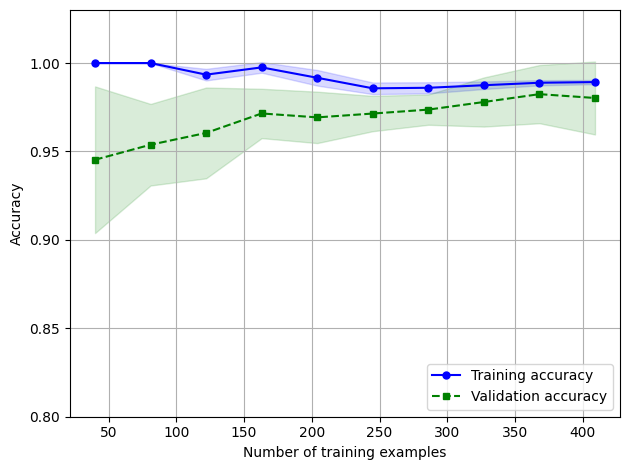

In [16]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve


pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(penalty='l2', max_iter=10000))

train_sizes, train_scores, test_scores =\
                learning_curve(estimator=pipe_lr,
                               X=X_train,
                               y=y_train,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.tight_layout()
# plt.savefig('figures/06_05.png', dpi=300)
plt.show()

<br>
<br>

## Addressing over- and underfitting with validation curves

This cell generates a validation curve, which is a plot of the training and validation accuracy as a function of a model parameter. Validation curves are a good way to see how a model's performance changes with different parameter values, which is useful for hyperparameter tuning.

The cell uses the `validation_curve` function from scikit-learn to calculate the training and validation scores for different values of the `C` parameter of the `LogisticRegression` model. The values of `C` to use are specified with a list: `[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]`.

The mean and standard deviation of the training and validation scores are then calculated. These are used to create the validation curve plot. The plot includes the training and validation accuracy scores, as well as the standard deviation of these scores, which is shown as a filled area around the lines.


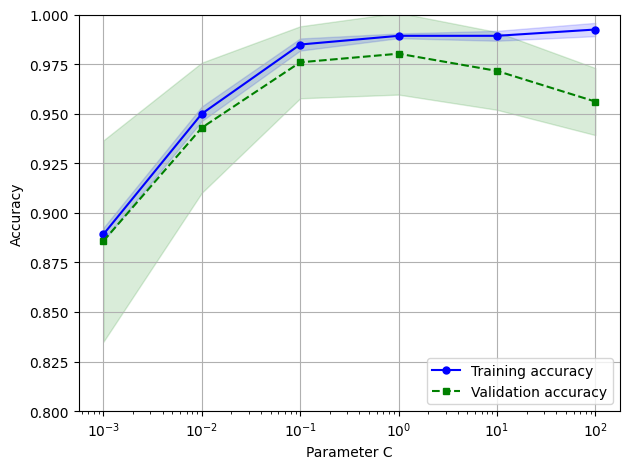

In [17]:
from sklearn.model_selection import validation_curve


param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
                estimator=pipe_lr,
                X=X_train,
                y=y_train,
                param_name='logisticregression__C',
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.tight_layout()
# plt.savefig('figures/06_06.png', dpi=300)
plt.show()

<br>
<br>

# Fine-tuning machine learning models via grid search

<br>
<br>

## Tuning hyperparameters via grid search

This cell demonstrates how to fine-tune the parameters of a machine learning model using grid search. Grid search is a method of hyperparameter tuning that involves training a model on each combination of a predefined set of hyperparameters and selecting the combination that performs best.

The cell first creates a pipeline with `StandardScaler` and `SVC`, a support vector machine classifier. It then defines a list of parameters to test in the grid search. The `param_grid` is a list of dictionaries, where each dictionary defines a set of hyperparameters and their possible values.

The grid search is performed by creating a `GridSearchCV` object and fitting it to the training data. The best score and the parameters that led to the best score are then printed.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1))

param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

param_grid = [{'svc__C': param_range,
               'svc__kernel': ['linear']},
              {'svc__C': param_range,
               'svc__gamma': param_range,
               'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  refit=True,
                  cv=10)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9846859903381642
{'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


This cell retrieves the best estimator from the grid search and uses it to calculate the accuracy on the test set. The `best_estimator_` attribute of `GridSearchCV` returns the estimator that gave the highest score on the left-out data in the cross-validation.

The cell also includes a commented-out call to `fit`. This is not necessary because the grid search automatically refits the best estimator on the whole training set, as indicated by the `refit=True` parameter.

Finally, the cell prints the accuracy of the best estimator on the test set.

In [19]:
clf = gs.best_estimator_

# clf.fit(X_train, y_train)
# note that we do not need to refit the classifier
# because this is done automatically via refit=True.

print(f'Test accuracy: {clf.score(X_test, y_test):.3f}')

Test accuracy: 0.974


This cell sets up a randomized search over hyperparameters. Unlike grid search, which tries out every possible combination of hyperparameters, randomized search picks a random subset of the hyperparameters for each iteration. This can be faster and more efficient, especially when the number of hyperparameters is large.

The cell creates a pipeline with `StandardScaler` and `SVC`, defines the hyperparameters to search over, and creates a `RandomizedSearchCV` instance with the pipeline, the hyperparameters, and other parameters such as the scoring metric, the number of iterations, and the number of folds for cross-validation.

In [20]:
from sklearn.model_selection import RandomizedSearchCV


pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=1))

param_grid = [{'svc__C': param_range,
               'svc__kernel': ['linear']},
              {'svc__C': param_range,
               'svc__gamma': param_range,
               'svc__kernel': ['rbf']}]


rs = RandomizedSearchCV(estimator=pipe_svc,
                        param_distributions=param_grid,
                        scoring='accuracy',
                        refit=True,
                        n_iter=20,
                        cv=10,
                        random_state=1,
                        n_jobs=-1)

This cell fits the randomized search to the training data. The `fit` method performs the randomized search over the specified hyperparameters and fits the best estimator to the training data. The cell then prints the best score obtained in the randomized search.

In [21]:
rs = rs.fit(X_train, y_train)
print(rs.best_score_)

0.9737681159420291


This cell prints the parameters of the best estimator found by the randomized search. The `best_params_` attribute of `RandomizedSearchCV` returns a dictionary of the parameters that gave the best score in the search.

In [22]:
print(rs.best_params_)

{'svc__kernel': 'rbf', 'svc__gamma': 0.001, 'svc__C': 10.0}


## Exploring hyperparameter configurations more widely with randomized search

In [23]:
Image(url=f'{FIGURES_BASE_URL}/06_11.png', width=600)


This cell shows how to generate random values for the hyperparameters in a logarithmic distribution.

Initially, `param_range` is defined as a list of eight values spread across several orders of magnitude. This is a common way to specify hyperparameters for models such as SVMs that are sensitive to the scale of the data.

Next, `param_range` is redefined as a log-uniform random variable using the `scipy.stats.loguniform` function. This random variable is defined over the interval [0.0001, 1000.0], the same range as the initial `param_range`.

Finally, the `rvs` method is called on `param_range` to generate 10 random values from this distribution. The random seed is set to 1 for reproducibility.

In [24]:
import scipy.stats


param_range = [0.0001, 0.001, 0.01, 0.1,
               1.0, 10.0, 100.0, 1000.0]

param_range = scipy.stats.loguniform(0.0001, 1000.0)

np.random.seed(1)
param_range.rvs(10)

array([8.30145146e-02, 1.10222804e+01, 1.00184520e-04, 1.30715777e-02,
       1.06485687e-03, 4.42965766e-04, 2.01289666e-03, 2.62376594e-02,
       5.98924832e-02, 5.91176467e-01])

## More resource-efficient hyperparameter search with successive halving

This cell imports the necessary modules to conduct a halving random search for hyperparameter tuning. The HalvingRandomSearchCV is an iterative way to conduct a randomized search, where the amount of resources allocated to each candidate at each iteration is halved, hence the name "halving" search.

In [25]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

This cell initializes a HalvingRandomSearchCV object. The parameters passed to this object are the pipeline estimator, the hyperparameter grid, the number of candidates to consider at each iteration (set to 'exhaust' to consider all candidates), the resource to allocate to each candidate (set to 'n_samples' to allocate training samples), the reduction factor at each iteration (set to 1.5), and the number of jobs to run in parallel for both fit and predict (set to -1 to use all processors).

In [26]:
hs = HalvingRandomSearchCV(
    pipe_svc,
    param_distributions=param_grid,
    n_candidates='exhaust',
    resource='n_samples',
    factor=1.5,
    random_state=1,
    n_jobs=-1)

This cell fits the HalvingRandomSearchCV object to the training data and prints the best score and the parameters of the best estimator found. The `fit` method performs the halving random search over the specified hyperparameters and fits the best estimator to the training data.

In [27]:
hs = hs.fit(X_train, y_train)
print(hs.best_score_)
print(hs.best_params_)

0.9676470588235293
{'svc__kernel': 'rbf', 'svc__gamma': 0.0001, 'svc__C': 100.0}


This cell retrieves the best estimator from the halving random search and uses it to calculate the accuracy on the test set. The `best_estimator_` attribute of `HalvingRandomSearchCV` returns the estimator that gave the highest score on the left-out data in the cross-validation.

In [28]:
clf = hs.best_estimator_
print(f'Test accuracy: {hs.score(X_test, y_test):.3f}')

Test accuracy: 0.965


<br>
<br>

## Algorithm selection with nested cross-validation

In [29]:
Image(url=f'{FIGURES_BASE_URL}/06_07.png', width=500)


This cell demonstrates how to use nested cross-validation for algorithm selection. Nested cross-validation is a method of evaluating how well a model generalizes to unseen data. It involves performing cross-validation on the inner loop (to tune the hyperparameters) and on the outer loop (to evaluate the model).

The cell first creates a `GridSearchCV` object like in the previous cell. However, instead of calling `fit` on this object, it is passed to the `cross_val_score` function. This means that for each fold in the outer loop, a grid search is performed to tune the hyperparameters, and the best model is evaluated.

Finally, the mean and standard deviation of the cross-validation accuracies are printed.

In [30]:
gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train,
                         scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f} '
      f'+/- {np.std(scores):.3f}')

CV accuracy: 0.974 +/- 0.015


This cell is similar to the previous one, but it uses a decision tree classifier instead of a support vector machine. The hyperparameters for the decision tree that are tuned in the grid search are different: it tunes the `max_depth` parameter, which controls the maximum depth of the tree.

In [31]:
from sklearn.tree import DecisionTreeClassifier

gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                  param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train,
                         scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f} '
      f'+/- {np.std(scores):.3f}')

CV accuracy: 0.934 +/- 0.016


<br>
<br>

# Looking at different performance evaluation metrics

...

## Reading a confusion matrix

In [32]:
Image(url=f'{FIGURES_BASE_URL}/06_08.png', width=300)


This cell demonstrates how to generate and print a confusion matrix, which is a table that describes the performance of a classification model.

The cell first fits the pipeline to the training data and makes predictions on the test data. Then, it calls the `confusion_matrix` function from scikit-learn, which computes the confusion matrix. This matrix provides a more detailed breakdown of correct and incorrect classifications for each class. The true labels and predicted labels are passed to the `confusion_matrix` function, which returns the matrix.

In [33]:
from sklearn.metrics import confusion_matrix

pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


This cell plots the confusion matrix as a color-coded heatmap. Each cell in the plot corresponds to a cell in the confusion matrix, and the color of the cell represents the value of that cell. Darker colors represent higher numbers.

The cell first creates a new figure with `plt.subplots`. Then, it uses `ax.matshow` to display the confusion matrix as a color-coded grid. A loop is used to add the actual numbers to each cell in the grid. Finally, the labels for the x and y axes are set, and the plot is displayed with `plt.show()`.

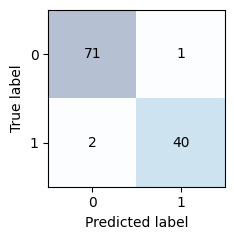

In [34]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
ax.xaxis.set_ticks_position('bottom')

plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.tight_layout()
#plt.savefig('figures/06_09.png', dpi=300)
plt.show()

### Additional Note

Remember that we previously encoded the class labels so that *malignant* examples are the "postive" class (1), and *benign* examples are the "negative" class (0):

In [35]:
le.transform(['M', 'B'])

array([1, 0])

In [36]:
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


Next, we printed the confusion matrix like so:

In [37]:
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


Note that the (true) class 0 examples that are correctly predicted as class 0 (true negatives) are now in the upper left corner of the matrix (index 0, 0). In order to change the ordering so that the true negatives are in the lower right corner (index 1,1) and the true positves are in the upper left, we can use the `labels` argument like shown below:

In [38]:
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred, labels=[1, 0])
print(confmat)

[[40  2]
 [ 1 71]]


We conclude:

Assuming that class 1 (malignant) is the positive class in this example, our model correctly classified 71 of the examples that belong to class 0 (true negatives) and 40 examples that belong to class 1 (true positives), respectively. However, our model also incorrectly misclassified 1 example from class 0 as class 1 (false positive), and it predicted that 2 examples are benign although it is a malignant tumor (false negatives).

<br>
<br>

## Optimizing the precision and recall of a classification model

This cell calculates and prints the precision, recall, and F1 score of the model's predictions. These are metrics that provide more information about the performance of a classification model beyond accuracy.

- Precision is the ratio of true positives (correct positive predictions) to all positive predictions (both true positives and false positives). It provides a measure of the model's ability to correctly identify positive instances.
- Recall (also known as sensitivity) is the ratio of true positives to all actual positives (both true positives and false negatives). It provides a measure of the model's ability to find all the positive instances.
- The F1 score is the harmonic mean of precision and recall. It provides a single metric that balances both precision and recall.
- Matthews Correlation Coefficient  (MCC) is a metric used in machine learning to measure the quality of binary classifications. It takes into account true and false positives and negatives and is generally regarded as a balanced measure which can be used even if the classes are of very different sizes.

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import matthews_corrcoef

pre_val = precision_score(y_true=y_test, y_pred=y_pred)
print(f'Precision: {pre_val:.3f}')

rec_val = recall_score(y_true=y_test, y_pred=y_pred)
print(f'Recall: {rec_val:.3f}')

f1_val = f1_score(y_true=y_test, y_pred=y_pred)
print(f'F1: {f1_val:.3f}')

mcc_val = matthews_corrcoef(y_true=y_test, y_pred=y_pred)
print(f'MCC: {mcc_val:.3f}')

Precision: 0.976
Recall: 0.952
F1: 0.964
MCC: 0.943


This cell demonstrates how to use a custom scorer in a grid search. The custom scorer is created using the `make_scorer` function from scikit-learn, with the F1 score as the score function and `pos_label=0`. This means that the F1 score will be calculated considering the label `0` as the positive class.

The cell then conducts a grid search similar to earlier cells, but it uses the custom scorer for scoring instead of the default scorer.

In [40]:
from sklearn.metrics import make_scorer

scorer = make_scorer(f1_score, pos_label=0)

c_gamma_range = [0.01, 0.1, 1.0, 10.0]

param_grid = [{'svc__C': c_gamma_range,
               'svc__kernel': ['linear']},
              {'svc__C': c_gamma_range,
               'svc__gamma': c_gamma_range,
               'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring=scorer,
                  cv=10,
                  n_jobs=-1)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9861994953378878
{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


<br>
<br>

## Plotting a receiver operating characteristic

This cell demonstrates how to plot a receiver operating characteristic (ROC) curve and calculate the area under the curve (AUC). An ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The AUC measures the entire two-dimensional area underneath the entire ROC curve.

The cell creates a pipeline with `StandardScaler`, `PCA`, and `LogisticRegression`. It then performs a 3-fold stratified cross-validation on the training data. For each fold, the model is fitted to the training split and the probabilities of the positive class are predicted for the test split. These probabilities, along with the true labels of the test split, are used to calculate the false positive rate (FPR), true positive rate (TPR), and thresholds for the ROC curve. The AUC is also calculated.

The ROC curve for each fold and the mean ROC curve are plotted. The plot also includes a line for random guessing (a diagonal dashed line) and perfect performance (a stepped line).

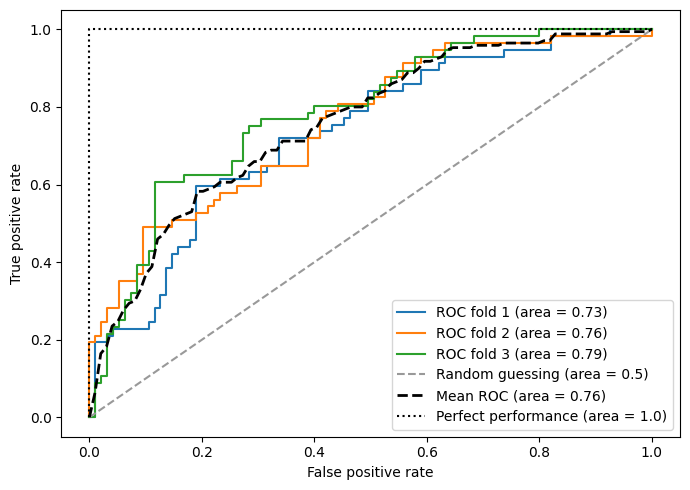

In [41]:
from sklearn.metrics import roc_curve, auc
from numpy import interp


pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(penalty='l2',
                                           random_state=1,
                                           solver='lbfgs',
                                           C=100.0))

X_train2 = X_train[:, [4, 14]]


cv = list(StratifiedKFold(n_splits=3).split(X_train, y_train))

fig = plt.figure(figsize=(7, 5))

mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train, test) in enumerate(cv):
    probas = pipe_lr.fit(X_train2[train],
                         y_train[train]).predict_proba(X_train2[test])

    fpr, tpr, thresholds = roc_curve(y_train[test],
                                     probas[:, 1],
                                     pos_label=1)
    mean_tpr += interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,
             tpr,
             label=f'ROC fold {i+1} (area = {roc_auc:.2f})')

plt.plot([0, 1],
         [0, 1],
         linestyle='--',
         color=(0.6, 0.6, 0.6),
         label='Random guessing (area = 0.5)')

mean_tpr /= len(cv)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, 'k--',
         label=f'Mean ROC (area = {mean_auc:.2f})', lw=2)
plt.plot([0, 0, 1],
         [0, 1, 1],
         linestyle=':',
         color='black',
         label='Perfect performance (area = 1.0)')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')

plt.tight_layout()
# plt.savefig('figures/06_10.png', dpi=300)
plt.show()

<br>
<br>

## The scoring metrics for multiclass classification

This cell creates a custom scorer that calculates the micro-averaged precision score. This scorer can then be used in functions like `cross_val_score` or `GridSearchCV` to score a model's predictions.

The `make_scorer` function from scikit-learn is used to create the custom scorer. It is called with the `precision_score` function, `pos_label=1`, `greater_is_better=True`, and `average='micro'`.

The `average='micro'` parameter calculates metrics globally by counting the total true positives, false negatives, and false positives, which is suitable for multiclass/multilabel tasks.

In [42]:
pre_scorer = make_scorer(score_func=precision_score,
                         pos_label=1,
                         greater_is_better=True,
                         average='micro')

## Dealing with class imbalance

This cell creates a new dataset with an imbalanced distribution of classes. It stacks vertically (vstack) the instances of class 0 and the first 40 instances of class 1 to form the new feature matrix `X_imb`. It also concatenates horizontally (hstack) the labels of class 0 and the first 40 labels of class 1 to form the new label vector `y_imb`.

In [43]:
X_imb = np.vstack((X[y == 0], X[y == 1][:40]))
y_imb = np.hstack((y[y == 0], y[y == 1][:40]))

This cell demonstrates the accuracy paradox in machine learning. It creates an array of zeros with the same length as `y_imb`, meaning that it predicts every instance as the negative class. It then calculates and returns the accuracy of these predictions.

In the context of the imbalanced dataset, the accuracy of this naive classifier is very high, because the majority of instances are negative. This demonstrates the accuracy paradox, which is that a trivial model with no predictive power can have a high accuracy if the classes are imbalanced.

In [44]:
y_pred = np.zeros(y_imb.shape[0])
np.mean(y_pred == y_imb) * 100

np.float64(89.92443324937027)

This cell demonstrates how to deal with class imbalance by upsampling the minority class. It uses the `resample` function from scikit-learn to randomly replicate instances from the minority class, which is class 1 in this case.

The cell first prints the number of instances in class 1 before the upsampling. Then, it calls the `resample` function with the instances of class 1, the labels of class 1, and the number of instances in class 0. This generates a new feature matrix and label vector (`X_upsampled` and `y_upsampled`) that have as many instances of class 1 as there are instances of class 0. Finally, the cell prints the number of instances in class 1 after the upsampling.


In [45]:
from sklearn.utils import resample

print('Number of class 1 examples before:', X_imb[y_imb == 1].shape[0])

X_upsampled, y_upsampled = resample(X_imb[y_imb == 1],
                                    y_imb[y_imb == 1],
                                    replace=True,
                                    n_samples=X_imb[y_imb == 0].shape[0],
                                    random_state=123)

print('Number of class 1 examples after:', X_upsampled.shape[0])

Number of class 1 examples before: 40
Number of class 1 examples after: 357


This cell combines the upsampled class 1 instances and the original class 0 instances to form a new, balanced dataset. It stacks vertically (vstack) the instances of class 0 and the upsampled instances of class 1 to form the new feature matrix `X_bal`. It also concatenates horizontally (hstack) the labels of class 0 and the upsampled labels of class 1 to form the new label vector `y_bal`.

In [46]:
X_bal = np.vstack((X[y == 0], X_upsampled))
y_bal = np.hstack((y[y == 0], y_upsampled))

This cell demonstrates again the accuracy paradox, but this time using the balanced dataset. It creates an array of zeros with the same length as `y_bal`, meaning that it predicts every instance as the negative class. It then calculates and returns the accuracy of these predictions.

In the context of the balanced dataset, the accuracy of this naive classifier is 50%, which is significantly lower than the accuracy on the imbalanced dataset. This demonstrates again that accuracy is not always a good metric for evaluating models, especially in the context of class imbalances.

In [47]:
y_pred = np.zeros(y_bal.shape[0])
np.mean(y_pred == y_bal) * 100

np.float64(50.0)

<br>
<br>

# Summary

...

---

Readers may ignore the next cell.

In [48]:
# This cell converts the notebook to a plain .py script using a helper script
# from the book's companion repo. It isn't needed to run the notebook itself,
# and the helper script isn't present on Colab, so it's skipped here.
# ! python ../.convert_notebook_to_script.py --input ch06.ipynb --output ch06.py


# Added By Brian Jalaian for Illustrainig Precision-Recall Curve

In [49]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

In [50]:
# generate a binary classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=10, random_state=1)

In [51]:
# split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [52]:
# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_train)

LogisticRegression()

In [53]:
# predict probabilities
y_scores = model.predict_proba(X_test)

In [54]:
# retrieve just the probabilities for the positive class
y_scores = y_scores[:, 1]

In [55]:
# calculate precision and recall for each threshold
precision, recall, _ = precision_recall_curve(y_test, y_scores)

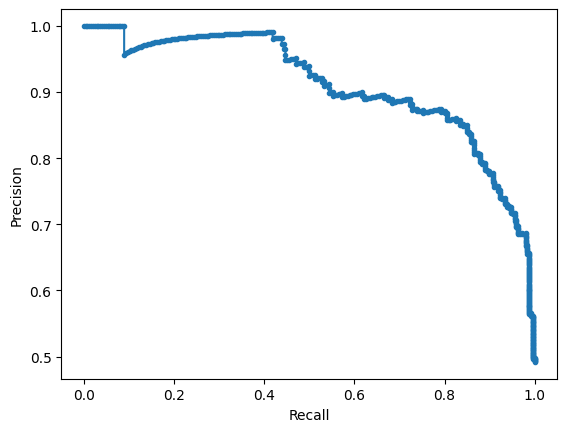

In [56]:
# plot the precision-recall curves
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

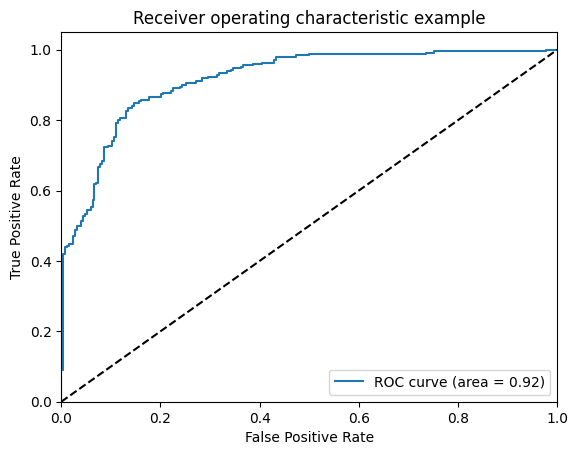

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# assuming y_test are the true labels and y_scores are the predicted scores
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()


In [58]:
from sklearn.metrics import precision_score

# Use predictions from the model trained earlier in this section (cell with `model.fit(...)`),
# rather than the unrelated `y_pred` from the class-imbalance demo above.
y_pred_cls = model.predict(X_test)
macro_precision = precision_score(y_test, y_pred_cls, average='macro')

print(f'Macro-Averaged Precision: {macro_precision:.2f}')


Macro-Averaged Precision: 0.85


In [59]:
from sklearn.utils import resample
import numpy as np

# Separate majority (0) and minority (1) classes in this section's training split
X_train_maj = X_train[y_train == 0]
X_train_min = X_train[y_train == 1]

print('Before upsampling -> majority:', X_train_maj.shape[0], 'minority:', X_train_min.shape[0])

# Upsample the minority class to match the majority class size
X_train_min_upsampled = resample(
    X_train_min,
    replace=True,          # sample with replacement
    n_samples=X_train_maj.shape[0],  # match number in majority class
    random_state=27)       # reproducible results

# Combine majority class with upsampled minority class
X_train_upsampled = np.vstack((X_train_maj, X_train_min_upsampled))
y_train_upsampled = np.hstack((
    np.zeros(X_train_maj.shape[0]),
    np.ones(X_train_min_upsampled.shape[0])))

print('After upsampling  -> total:', X_train_upsampled.shape[0],
      '(class balance: %.2f)' % y_train_upsampled.mean())


Before upsampling -> majority: 243 minority: 257
After upsampling  -> total: 486 (class balance: 0.50)
